In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

sns.set_style("whitegrid")


In [2]:
df = pd.read_csv("C:/Users/VIKAS/Desktop/Disease_Prediction_Project/data/thyroidDF.csv")
df.head()


,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,target,patient_id
0,29,F,f,f,f,f,f,f,f,t,...,NaN,f,NaN,f,NaN,f,NaN,other,-,840801013
1,29,F,f,f,f,f,f,f,f,f,...,128.0,f,NaN,f,NaN,f,NaN,other,-,840801014
2,41,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,11.0,other,-,840801042
3,36,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,26.0,other,-,840803046
4,32,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,36.0,other,S,840803047


<class 'pandas.DataFrame'>
RangeIndex: 9172 entries, 0 to 9171
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  9172 non-null   int64  
 1   sex                  8865 non-null   str    
 2   on_thyroxine         9172 non-null   str    
 3   query_on_thyroxine   9172 non-null   str    
 4   on_antithyroid_meds  9172 non-null   str    
 5   sick                 9172 non-null   str    
 6   pregnant             9172 non-null   str    
 7   thyroid_surgery      9172 non-null   str    
 8   I131_treatment       9172 non-null   str    
 9   query_hypothyroid    9172 non-null   str    
 10  query_hyperthyroid   9172 non-null   str    
 11  lithium              9172 non-null   str    
 12  goitre               9172 non-null   str    
 13  tumor                9172 non-null   str    
 14  hypopituitary        9172 non-null   str    
 15  psych                9172 non-null   str    
 16 

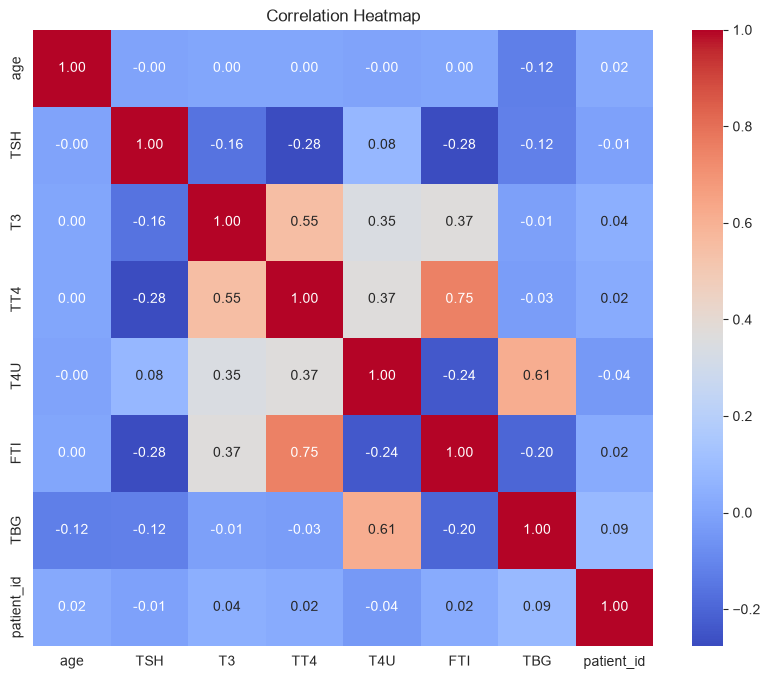

In [3]:
print(df.info())
print(df.describe())
print("\nMissing values:\n", df.isnull().sum())
print("\nClass balance:\n", df['target'].value_counts())

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [4]:
df = df.drop(columns=[c for c in ['patient_id', 'TBG', 'TBG_measured', 'referral_source'] if c in df.columns])

df['target'] = df['target'].apply(lambda x: 0 if str(x).strip() == '-' else 1)

tf_cols = df.select_dtypes(include='object').columns.tolist()
tf_cols = [c for c in tf_cols if c != 'sex' and set(df[c].dropna().unique()).issubset({'t', 'f'})]
for col in tf_cols:
    df[col] = df[col].map({'t': 1, 'f': 0})

if 'sex' in df.columns:
    df['sex'] = df['sex'].map({'M': 1, 'F': 0})

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col], errors='coerce')

for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


C:\Users\VIKAS\AppData\Local\Temp\ipykernel_19476\2928220336.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  tf_cols = df.select_dtypes(include='object').columns.tolist()


In [5]:
models = {
    "random_forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "svm": SVC(probability=True, random_state=42),
    "knn": KNeighborsClassifier(n_neighbors=5)
}

trained_models = {}
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1})
    trained_models[name] = model

    print(f"\n--- {name} ---")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False)
results_df



--- random_forest ---
[[1296   59]
 [  35  445]]
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1355
           1       0.88      0.93      0.90       480

    accuracy                           0.95      1835
   macro avg       0.93      0.94      0.93      1835
weighted avg       0.95      0.95      0.95      1835



C:\Users\VIKAS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



--- svm ---
[[1310   45]
 [ 192  288]]
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1355
           1       0.86      0.60      0.71       480

    accuracy                           0.87      1835
   macro avg       0.87      0.78      0.81      1835
weighted avg       0.87      0.87      0.86      1835



C:\Users\VIKAS\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\VIKAS\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\VIKAS\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\VIKAS\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", l


--- knn ---
[[1308   47]
 [ 193  287]]
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1355
           1       0.86      0.60      0.71       480

    accuracy                           0.87      1835
   macro avg       0.87      0.78      0.81      1835
weighted avg       0.87      0.87      0.86      1835



,model,accuracy,precision,recall,f1
0,random_forest,0.948774,0.882937,0.927083,0.904472
1,svm,0.870845,0.864865,0.600000,0.708487
2,knn,0.869210,0.859281,0.597917,0.705160


In [6]:
os.makedirs('../models/thyroid', exist_ok=True)

for name, model in trained_models.items():
    joblib.dump(model, f'../models/thyroid/{name}.pkl')

joblib.dump(scaler, '../models/thyroid/scaler.pkl')
results_df.to_json('../models/thyroid/metrics.json', orient='records')

print("Saved all models, scaler, and metrics.")


Saved all models, scaler, and metrics.


In [7]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

shap.initjs()


In [8]:
disease = "thyroid"
best_model_name = "random_forest"   # <-- replace with your actual best model from results_df above

model = joblib.load(f'../models/{disease}/{best_model_name}.pkl')
scaler = joblib.load(f'../models/{disease}/scaler.pkl')

df = pd.read_csv("C:/Users/VIKAS/Desktop/Disease_Prediction_Project/data/thyroidDF.csv")
df = df.drop(columns=[c for c in ['patient_id', 'TBG', 'TBG_measured', 'referral_source'] if c in df.columns])
df['target'] = df['target'].apply(lambda x: 0 if str(x).strip() == '-' else 1)

tf_cols = df.select_dtypes(include='object').columns.tolist()
tf_cols = [c for c in tf_cols if c != 'sex' and set(df[c].dropna().unique()).issubset({'t', 'f'})]
for col in tf_cols:
    df[col] = df[col].map({'t': 1, 'f': 0})
if 'sex' in df.columns:
    df['sex'] = df['sex'].map({'M': 1, 'F': 0})
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col], errors='coerce')
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

X = df.drop('target', axis=1)
feature_names = X.columns.tolist()
X_scaled = scaler.transform(X)


C:\Users\VIKAS\AppData\Local\Temp\ipykernel_19476\3245374321.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  tf_cols = df.select_dtypes(include='object').columns.tolist()


In [9]:
# Tree-based models (RandomForest, XGBoost, DecisionTree) -> TreeExplainer (fast)
# Others (LogisticRegression, SVM, KNN, Naive Bayes) -> KernelExplainer (slower, needs background sample)

tree_models = ["random_forest", "xgboost", "decision_tree"]

# Sample rows for speed - full dataset explanation isn't needed for the summary plot
X_shap_sample = X_scaled[:300]

if best_model_name in tree_models:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap_sample)
    # For binary classifiers, shap_values may be a list [class0, class1] -> take class 1
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
else:
    background = shap.sample(X_scaled, 100, random_state=42)
    explainer = shap.KernelExplainer(model.predict_proba, background)
    shap_values = explainer.shap_values(X_scaled[:100])  # limit rows, KernelExplainer is slow


<Figure size 640x480 with 0 Axes>

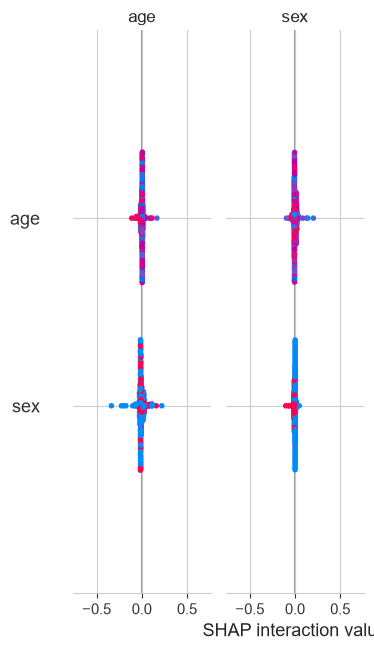

In [10]:
plt.figure()
shap.summary_plot(shap_values, X_shap_sample if best_model_name in tree_models else X_scaled[:100],
                   feature_names=feature_names, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig(f'../models/{disease}/shap_summary_bar.png', dpi=150)
plt.show()


<Figure size 640x480 with 0 Axes>

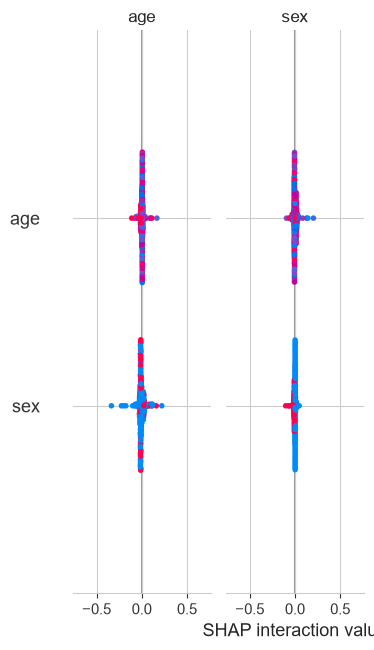

In [11]:
plt.figure()
shap.summary_plot(shap_values, X_shap_sample if best_model_name in tree_models else X_scaled[:100],
                   feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig(f'../models/{disease}/shap_summary_beeswarm.png', dpi=150)
plt.show()


In [12]:
def explain_single_prediction(patient_row_scaled, explainer, feature_names, is_tree_model):

    # Get SHAP values
    if is_tree_model:
        sv = explainer.shap_values(patient_row_scaled)

        # Binary classification case
        if isinstance(sv, list):
            sv = sv[1]

        sv = sv[0]  # take first sample

    else:
        sv = explainer.shap_values(patient_row_scaled)

        # Binary classification case
        if isinstance(sv, list):
            sv = sv[1]

        sv = sv[0]

    # Important fix
    sv = np.array(sv).reshape(-1)   # ensures 1D

    # Create dataframe
    impact_df = pd.DataFrame({
        "feature": feature_names,
        "shap_value": sv
    })

    impact_df["abs_impact"] = impact_df["shap_value"].abs()

    return impact_df.sort_values("abs_impact", ascending=False)
